# Análisis Plan de Compras 2025

## Carga de planilla

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("../plan_de_compras_2025.xlsx")
df.head()

,Unidad de Compra,ID Proyecto,Tipo Proyecto,Estado Proyecto,Código presupuestario,Nombre Proyecto,Descripción Proyecto,Cantidad de Ítems,Nombre ítem,Tipo compra,...,Cargo responsable,Teléfono responsable,Correo responsable,Fecha de Inicio Compra,Fecha Publicación PAC 2025,Cantidad OC Asociadas Ítem 2025,OC Asociada Item 2025,Item De Arraste,Monto De Arrastre,Meses envio OC de Arraste
0,Ministerio de Vivienda y Urbanismo(766),587-259-PC22,Proyecto estratégico,Publicado,2207-2209-33,Servicio arriendo de una plataforma de gestión...,Servicio de arriendo de una plataforma de gest...,2,Servicio arriendo de una plataforma de gestión...,1,...,Coordinadora de Tecnologías Informáticas | Sis...,2 -2901 1198-,mzunigas@minvu.cl,2022-11-01,2022-11-08,0,NaN,1,20000000,2025-01-01
1,SEREMI MINVU V REGION,632-28-PC22,Proyecto operacional,Publicado,2206-2206001,Servicio de Mantención y Reparaciones Menores ...,Convenio de Suministro para el Servicio de Man...,1,Mantenimiento y Reparación de Edificaciones,1,...,Encargado Sección Administración y Finanzas,32-2186802-,agardaix@minvu.cl,2022-02-01,2022-11-08,1,632-7-SE22,1,4500000,2025-01-01
2,SEREMI MINVU V REGION,632-32-PC22,Proyecto operacional,Publicado,2204001,Servicios de Impresión-Seremi Valparaiso,Servicios de Impresión de Materiales SEREMI y ...,1,Materiales de Oficina,1,...,Encargado Sección Administración y Finanzas,32-2186802-,agardaix@minvu.cl,2022-08-01,2022-11-08,0,NaN,1,3825000,2025-01-01
3,SEREMI MINVU V REGION,632-34-PC22,Proyecto operacional,Publicado,2209006,Servicio de Arriendo de Impresoras Multifuncio...,Servicio de Arriendo de Impresoras Multifuncio...,2,Arriendo de Equipos Informáticos,1,...,Encargado Sección Administración y Finanzas,32-2186802-,agardaix@minvu.cl,2022-08-01,2022-11-08,1,632-13-CC23,1,4500000,2025-01-01
4,SEREMI MINVU V REGION,632-41-PC22,Proyecto operacional,Publicado,2205005,Servicio de Telefonía Fija-Seremi Valparaiso,Servicio de Telefonía Fija SEREMI,2,Telefonía Fija,1,...,Encargado Sección Administración y Finanzas,322186802,agardaix@minvu.cl,2022-12-01,2022-11-08,0,NaN,1,26400000,2025-01-01


## 1.- Análisis Exploratorio (EDA)

### 1.1 Dimensiones y estructura general

In [2]:
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
print()
df.info()

Filas: 831
Columnas: 26

<class 'pandas.DataFrame'>
RangeIndex: 831 entries, 0 to 830
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Unidad de Compra                 831 non-null    str           
 1   ID Proyecto                      831 non-null    str           
 2   Tipo Proyecto                    831 non-null    str           
 3   Estado Proyecto                  831 non-null    str           
 4   Código presupuestario            830 non-null    object        
 5   Nombre Proyecto                  831 non-null    str           
 6   Descripción Proyecto             831 non-null    str           
 7   Cantidad de Ítems                831 non-null    int64         
 8   Nombre ítem                      831 non-null    str           
 9   Tipo compra                      831 non-null    int64         
 10  Cantidad Productos               831 non-null   

**Corrección/mejora:** `df.info()` solo muestra si hay o no valores nulos indirectamente
(vía "Non-Null Count"), pero conviene calcular explícitamente los nulos y duplicados,
que es un paso estándar de todo EDA.

In [3]:
# Valores nulos por columna
nulos = df.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
print("Columnas con valores nulos:")
print(nulos if len(nulos) > 0 else "No hay valores nulos")

print()
# Filas duplicadas
print(f"Filas duplicadas: {df.duplicated().sum()}")

Columnas con valores nulos:
Meses envio OC de Arraste    648
OC Asociada Item 2025        123
Código presupuestario          1
dtype: int64

Filas duplicadas: 0


### 1.2 Estadísticas descriptivas

In [4]:
# Variables numéricas
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Cantidad de Ítems,831.0,1.199759,1.0,1.0,1.0,1.0,3.0,0.414845
Tipo compra,831.0,4.65704,1.0,4.0,6.0,6.0,6.0,1.942318
Cantidad Productos,831.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0
Monto Unitario Ítem,831.0,108521418.050542,90000.0,4200000.0,40000000.0,202000000.0,4839000000.0,203621987.122704
Monto Total Ítem Año 2025,831.0,101485297.65343,0.0,3000000.0,35000000.0,202000000.0,4839000000.0,202466268.060846
Cantidad OC,831.0,1.344164,1.0,1.0,1.0,1.0,12.0,1.263753
Fecha de Inicio Compra,831,2024-11-24 15:32:16.462093,2022-02-01 00:00:00,2025-01-01 00:00:00,2025-01-01 00:00:00,2025-04-01 00:00:00,2026-03-01 00:00:00,NaN
Fecha Publicación PAC 2025,831,2025-07-25 18:37:41.371841,2022-11-08 00:00:00,2025-11-27 00:00:00,2025-11-27 00:00:00,2025-11-27 00:00:00,2025-11-27 00:00:00,NaN
Cantidad OC Asociadas Ítem 2025,831.0,125.756919,0.0,1.0,4.0,321.0,321.0,155.041024
Item De Arraste,831.0,0.220217,0.0,0.0,0.0,0.0,1.0,0.414642


**Corrección importante:** `Tipo compra` es numérica en el archivo, pero en realidad es un
**código categórico** (representa un tipo de compra, valores 1 a 6), no una cantidad.
Por eso su media/desviación estándar en `describe()` no tienen sentido y no deben
interpretarse como una medida real. Se recomienda tratarla como categoría:

In [5]:
print("Valores únicos de 'Tipo compra':", sorted(df["Tipo compra"].unique()))
df["Tipo compra"].value_counts().sort_index()

Valores únicos de 'Tipo compra': [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


Tipo compra
1    159
2      4
3     20
4     83
5     79
6    486
Name: count, dtype: int64

In [6]:
# Variables categóricas (texto)
df.describe(include="object")

/tmp/ipykernel_553/2588053988.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Unidad de Compra,ID Proyecto,Tipo Proyecto,Estado Proyecto,Código presupuestario,Nombre Proyecto,Descripción Proyecto,Nombre ítem,Meses envío OC,Nombre responsable,Cargo responsable,Teléfono responsable,Correo responsable,OC Asociada Item 2025
count,831,831,831,831,830,831,831,831,831,831,831,831,831,708
unique,16,326,2,2,73,328,297,317,59,85,81,96,64,657
top,Ministerio de Vivienda y Urbanismo(766),1583-200-PC25,Proyecto operacional,Actualizado,2208007,ADQUISICIÓN PASAJES - SECCION GESTION DE COMPRAS,Cubrir la necesidad de traslado de los funcion...,ADQUISICIÓN PASAJES - SECCION GESTION DE COMPRAS,2025-01-01 00:00:00,"MALHUE GUIÑEZ, MARIA ANGELICA",Enc. Seccion Gestión de Compras,02-29011155-,mmalhueg@minvu.cl,587-227-SE26
freq,684,321,613,648,332,321,321,321,339,325,325,325,325,2


### 1.3 Vista previa de los datos

In [7]:
df.head()

,Unidad de Compra,ID Proyecto,Tipo Proyecto,Estado Proyecto,Código presupuestario,Nombre Proyecto,Descripción Proyecto,Cantidad de Ítems,Nombre ítem,Tipo compra,...,Cargo responsable,Teléfono responsable,Correo responsable,Fecha de Inicio Compra,Fecha Publicación PAC 2025,Cantidad OC Asociadas Ítem 2025,OC Asociada Item 2025,Item De Arraste,Monto De Arrastre,Meses envio OC de Arraste
0,Ministerio de Vivienda y Urbanismo(766),587-259-PC22,Proyecto estratégico,Publicado,2207-2209-33,Servicio arriendo de una plataforma de gestión...,Servicio de arriendo de una plataforma de gest...,2,Servicio arriendo de una plataforma de gestión...,1,...,Coordinadora de Tecnologías Informáticas | Sis...,2 -2901 1198-,mzunigas@minvu.cl,2022-11-01,2022-11-08,0,NaN,1,20000000,2025-01-01
1,SEREMI MINVU V REGION,632-28-PC22,Proyecto operacional,Publicado,2206-2206001,Servicio de Mantención y Reparaciones Menores ...,Convenio de Suministro para el Servicio de Man...,1,Mantenimiento y Reparación de Edificaciones,1,...,Encargado Sección Administración y Finanzas,32-2186802-,agardaix@minvu.cl,2022-02-01,2022-11-08,1,632-7-SE22,1,4500000,2025-01-01
2,SEREMI MINVU V REGION,632-32-PC22,Proyecto operacional,Publicado,2204001,Servicios de Impresión-Seremi Valparaiso,Servicios de Impresión de Materiales SEREMI y ...,1,Materiales de Oficina,1,...,Encargado Sección Administración y Finanzas,32-2186802-,agardaix@minvu.cl,2022-08-01,2022-11-08,0,NaN,1,3825000,2025-01-01
3,SEREMI MINVU V REGION,632-34-PC22,Proyecto operacional,Publicado,2209006,Servicio de Arriendo de Impresoras Multifuncio...,Servicio de Arriendo de Impresoras Multifuncio...,2,Arriendo de Equipos Informáticos,1,...,Encargado Sección Administración y Finanzas,32-2186802-,agardaix@minvu.cl,2022-08-01,2022-11-08,1,632-13-CC23,1,4500000,2025-01-01
4,SEREMI MINVU V REGION,632-41-PC22,Proyecto operacional,Publicado,2205005,Servicio de Telefonía Fija-Seremi Valparaiso,Servicio de Telefonía Fija SEREMI,2,Telefonía Fija,1,...,Encargado Sección Administración y Finanzas,322186802,agardaix@minvu.cl,2022-12-01,2022-11-08,0,NaN,1,26400000,2025-01-01


In [8]:
df.tail()

,Unidad de Compra,ID Proyecto,Tipo Proyecto,Estado Proyecto,Código presupuestario,Nombre Proyecto,Descripción Proyecto,Cantidad de Ítems,Nombre ítem,Tipo compra,...,Cargo responsable,Teléfono responsable,Correo responsable,Fecha de Inicio Compra,Fecha Publicación PAC 2025,Cantidad OC Asociadas Ítem 2025,OC Asociada Item 2025,Item De Arraste,Monto De Arrastre,Meses envio OC de Arraste
826,Ministerio de Vivienda y Urbanismo(766),1583-334-PC25,Proyecto estratégico,Actualizado,2211001,Análisis Plan Regulador Comunal de Padre las C...,Análisis Plan Regulador Comunal de Padre las C...,1,Art. Aseo e higiene,4,...,Jefe Departamento Desarrollo Urbano,45-2964258-4258,abratz@minvu.cl,2025-10-01,2025-11-27,0,NaN,0,0,NaT
827,Ministerio de Vivienda y Urbanismo(766),1583-335-PC25,Proyecto estratégico,Actualizado,2211002,"SELICO 730 - ""Curso Manejo de Conflictos y Ges...","El Ministerio de Vivienda y Urbanismo, en adel...",1,Curso Manejo de Conflictos y Gestión de Acuerd...,6,...,Analista de Capacitación,29-011467-1467,npenna@minvu.cl,2025-10-01,2025-11-27,1,587-706-AG25,0,0,NaT
828,Ministerio de Vivienda y Urbanismo(766),1583-336-PC25,Proyecto estratégico,Actualizado,2211002,SELICO 737 - Curso Estatuto Administrativo,"El Ministerio de Vivienda y Urbanismo, en adel...",1,Curso estatuto administrativo,6,...,Analista Capacitación,22-9012465-2465,jarojasv@minvu.cl,2025-10-01,2025-11-27,0,NaN,0,0,NaT
829,Ministerio de Vivienda y Urbanismo(766),1583-337-PC25,Proyecto estratégico,Actualizado,2211002,"SELICO 744 - Curso ""GESTOR (A) PARA LA INCLUSI...","El Ministerio de Vivienda y Urbanismo, en adel...",1,"SELICO 744 - Curso ""GESTOR (A) PARA LA INCLUSI...",6,...,Analista de Capacitación,22-901 1467-1467,npenna@minvu.cl,2025-10-01,2025-11-27,1,587-730-AG25,0,0,NaT
830,Ministerio de Vivienda y Urbanismo(766),1583-338-PC25,Proyecto estratégico,Actualizado,2211002,"SELICO 749 - Curso ""Gestión de Compras para Un...",Curso sobre actualización de compras públicas ...,1,Curso Gestión de Compras para Unidades Require...,6,...,Analista de Capacitación,22-901 1467-1467,npenna@minvu.cl,2025-10-01,2025-11-27,1,587-733-AG25,0,0,NaT


### 1.4 Exploración de categorías clave

In [9]:
print("Estado Proyecto:")
print(df["Estado Proyecto"].value_counts())
print()
print("Tipo Proyecto:")
print(df["Tipo Proyecto"].value_counts())
print()
print("Top 10 Unidad de Compra:")
print(df["Unidad de Compra"].value_counts().head(10))

Estado Proyecto:
Estado Proyecto
Actualizado    648
Publicado      183
Name: count, dtype: int64

Tipo Proyecto:
Tipo Proyecto
Proyecto operacional    613
Proyecto estratégico    218
Name: count, dtype: int64

Top 10 Unidad de Compra:
Unidad de Compra
Ministerio de Vivienda y Urbanismo(766)    684
SEREMI MINVU V REGION                       30
SEREMI MINVU III REGION                     25
SEREMI MINVU VI REGION                      20
SEREMI IV REGION                            14
SEREMI MINVU REGION ARICA Y PARINACOTA       9
SEREMI MINVU XI REGION                       8
SEREMI MINVU II REGION                       8
SEREMI MINVU I REGION                        7
SEREMI VIII REGION                           6
Name: count, dtype: int64


## 5.- Análisis de fechas

In [10]:
# Asegurar formato datetime (por si acaso)
df["Fecha de Inicio Compra"] = pd.to_datetime(df["Fecha de Inicio Compra"], errors="coerce")
df["Fecha Publicación PAC 2025"] = pd.to_datetime(df["Fecha Publicación PAC 2025"], errors="coerce")

# Cuántas fechas no se pudieron convertir (quedaron como NaT)
print("Fechas inválidas en 'Fecha de Inicio Compra':", df["Fecha de Inicio Compra"].isna().sum())
print("Fechas inválidas en 'Fecha Publicación PAC 2025':", df["Fecha Publicación PAC 2025"].isna().sum())

Fechas inválidas en 'Fecha de Inicio Compra': 0
Fechas inválidas en 'Fecha Publicación PAC 2025': 0


**Mejora:** antes de calcular mínimos/máximos y restas de fechas, conviene comprobar
cuántos valores quedaron como `NaT` (fecha inválida) tras la conversión. En este archivo no
hay ninguno, pero es un chequeo que siempre se debe dejar en el notebook por si la planilla
cambia.

In [11]:
# 1. Rango de fechas
print("Fecha de Inicio Compra:")
print("  Mínima:", df["Fecha de Inicio Compra"].min())
print("  Máxima:", df["Fecha de Inicio Compra"].max())

print()
print("Fecha Publicación PAC 2025:")
print("  Mínima:", df["Fecha Publicación PAC 2025"].min())
print("  Máxima:", df["Fecha Publicación PAC 2025"].max())

Fecha de Inicio Compra:
  Mínima: 2022-02-01 00:00:00
  Máxima: 2026-03-01 00:00:00

Fecha Publicación PAC 2025:
  Mínima: 2022-11-08 00:00:00
  Máxima: 2025-11-27 00:00:00


In [12]:
# 2. Extraer año y mes para agrupar
df["Año Inicio Compra"] = df["Fecha de Inicio Compra"].dt.year
df["Mes Inicio Compra"] = df["Fecha de Inicio Compra"].dt.month

# 3. Cantidad de compras por año
compras_por_anio = df.groupby("Año Inicio Compra").size().reset_index(name="cantidad")
compras_por_anio

,Año Inicio Compra,cantidad
0,2022,11
1,2023,76
2,2024,96
3,2025,644
4,2026,4


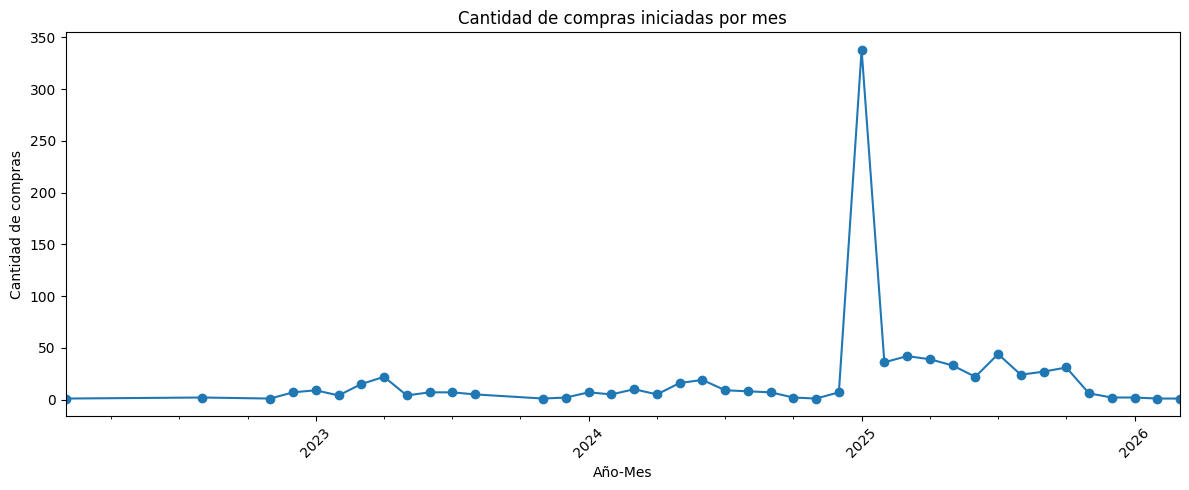

In [13]:
# 4. Cantidad de compras por mes (agrupado por año-mes)
df["AñoMes"] = df["Fecha de Inicio Compra"].dt.to_period("M")
compras_por_mes = df.groupby("AñoMes").size()

plt.figure(figsize=(12, 5))
compras_por_mes.plot(kind="line", marker="o")
plt.title("Cantidad de compras iniciadas por mes")
plt.xlabel("Año-Mes")
plt.ylabel("Cantidad de compras")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
# 5. Diferencia en días entre publicación PAC e inicio de compra
df["Dias_entre_PAC_e_Inicio"] = (df["Fecha de Inicio Compra"] - df["Fecha Publicación PAC 2025"]).dt.days
print("Estadísticas de días entre Publicación PAC e Inicio de Compra:")
print(df["Dias_entre_PAC_e_Inicio"].describe())

Estadísticas de días entre Publicación PAC e Inicio de Compra:
count    831.000000
mean    -243.128761
std      100.040228
min     -363.000000
25%     -330.000000
50%     -273.000000
75%     -151.000000
max       94.000000
Name: Dias_entre_PAC_e_Inicio, dtype: float64


**Corrección/observación importante (faltaba en la versión original):**
El cálculo estaba bien hecho, pero faltaba interpretar el resultado. La media es
**negativa (-243 días)** y el **98% de los casos (815 de 831)** tiene un valor negativo.
Esto significa que, según los datos, la **fecha de inicio de compra ocurre antes que la
fecha de publicación del PAC 2025**, lo cual es contraintuitivo (uno esperaría que el PAC
se publique primero y luego comiencen las compras). Vale la pena dejarlo documentado como
un hallazgo a validar con quien entregó la planilla, no asumir que es un error de cálculo.

Compras que inician ANTES de publicado el PAC: 815 (98.1%)
Compras que inician DESPUÉS (o el mismo día): 16 (1.9%)


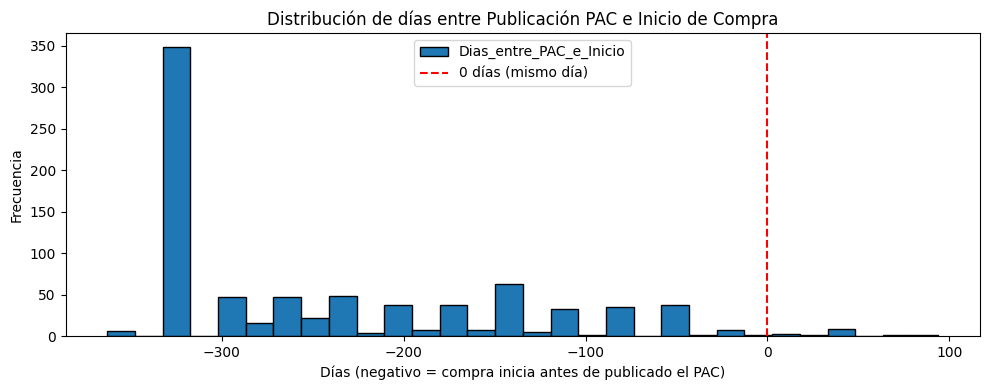

In [15]:
# ¿Cuántos casos tienen inicio de compra ANTES de la publicación del PAC?
casos_negativos = (df["Dias_entre_PAC_e_Inicio"] < 0).sum()
casos_positivos = (df["Dias_entre_PAC_e_Inicio"] >= 0).sum()
print(f"Compras que inician ANTES de publicado el PAC: {casos_negativos} ({casos_negativos/len(df):.1%})")
print(f"Compras que inician DESPUÉS (o el mismo día): {casos_positivos} ({casos_positivos/len(df):.1%})")

plt.figure(figsize=(10, 4))
df["Dias_entre_PAC_e_Inicio"].plot(kind="hist", bins=30, edgecolor="black")
plt.axvline(0, color="red", linestyle="--", label="0 días (mismo día)")
plt.title("Distribución de días entre Publicación PAC e Inicio de Compra")
plt.xlabel("Días (negativo = compra inicia antes de publicado el PAC)")
plt.ylabel("Frecuencia")
plt.legend()
plt.tight_layout()
plt.show()